# Demo -- evaluate fine-tuned PARNET (spliceosome HepG2)

## Set-up

### Imports

In [1]:
import pylbsr.notebooks
import pylbsr.misc

import io
import json
import math
import torch
import torch.utils.data
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import yaml
from pathlib import Path
from tqdm import tqdm
from scipy.stats import rankdata, pearsonr, spearmanr
from dotmap import DotMap
from typing import Literal

from parnet_additional_utils import (
    load_parnet_model,
    load_parnet_model_from_statedict,
    ParnetModelName,
    GzListDataset,
    HFDSDataset,
)

/home/lhofer/pixi-envs/parnet--unified-7433550039317049837/envs/parnet-dev-cu12/lib/python3.10/site-packages/gin/config.py:615: FutureWarning: `NLLLoss2d` has been deprecated. Please use `NLLLoss` instead as a drop-in replacement and see https://pytorch.org/docs/main/nn.html#torch.nn.NLLLoss for more details.
  decorated_class = decorating_meta(cls.__name__, (cls,), overrides)
Seed set to 42


### Initialization

In [3]:
_notebook_name = "evaluate_retrained_models.py.ipynb"
_notebook_path = f"notebooks/explore/{_notebook_name}"

pylbsr.notebooks.enable_cell_timing_metadata(show=True)

logger = pylbsr.misc.init_logger(_notebook_name)

PROJECT_DIR = pylbsr.notebooks.find_project_root_from_notebook_path(_notebook_path)
logger.info(f"Project directory: {PROJECT_DIR}")

[15:20:31] INFO - Project directory: /mnt/storage1/workspace/lhofer/parnet--globalclip-head


⏱ 0.01 s (00:00:00)


### Parameters

In [4]:
params_gpu_index = 0

# Set to the value of params_name_of_resulting_model used during training.
# The folder results/spliceosome-hepg2/training/{params_run_id}/
# must contain run_config.yaml, model.statedict.pt, csv_logs/, and checkpoints/.
params_run_id = "parnet.7m-0.0.ft-head.spliceosome-hepg2"

# Must match the params_dataset_format used during training (also stored in run_config.yaml).
params_dataset_format: Literal["pt", "hfds"] = "pt"

# Optional: path to an alternative test dataset.
# Format is auto-detected: a directory → HFDSDataset; a file → GzListDataset.
# Set to None to use the default path from run_config (params_dataset_format above).
params_test_dataset_path_override: str | None = None

# RBP names to show in the profile comparison plot (without _HepG2 suffix).
params_show_rbp_names = ["PRPF8", "U2AF2", "AQR"]

# ── Evaluation filters ──────────────────────────────────────────────────────
PARAMS_MIN_RC_SUM = 10    # minimum total eCLIP read count to include a tile in correlation analysis
PARAMS_MIN_TILES_BOX = 5  # minimum number of valid tiles for an RBP to appear in boxplot

⏱ 0.00 s (00:00:00)


In [5]:
# NOTE: THIS CELL MIGHT REQUIRE MANUAL ADJUSTMENT FOR THE GPU TO USE.
pylbsr.misc.set_seed(42)

device = torch.device(f"cuda:{params_gpu_index}")
torch.cuda.set_device(params_gpu_index)

if torch.cuda.is_available():
    logger.info(f"Using GPU: {torch.cuda.get_device_name(device)}")
else:
    logger.warning("No GPU available, using CPU instead.")

[15:22:31] INFO - Using GPU: NVIDIA RTX A4000


Seed set to 42
⏱ 0.10 s (00:00:00)


### Filepaths

In [6]:
_run_dir = (
    PROJECT_DIR / "results" / "spliceosome-hepg2"
    / "training" / params_run_id
)

_run_cfg_path = _run_dir / "run_config.yaml"
assert _run_cfg_path.exists(), f"run_config.yaml not found: {_run_cfg_path}"

_run_cfg = yaml.safe_load(_run_cfg_path.read_text())
logger.info(f"Loaded run config from {_run_cfg_path}")

# params_dataset_format from yaml takes precedence over the user-set value (backward-compat fallback)
params_dataset_format = _run_cfg.get("params_dataset_format", params_dataset_format)

_fp_cfg = yaml.safe_load((PROJECT_DIR / "config" / "filepaths.yaml").read_text())


def _res(p):
    p = Path(p)
    return p if p.is_absolute() else PROJECT_DIR / p


pretrained_model_name = ParnetModelName(_run_cfg["pretrained_model_name"])

FILEPATHS = DotMap()
FILEPATHS["pretrained_model"] = _res(_fp_cfg["models"][pretrained_model_name.value])
FILEPATHS["filtered_dataset"] = PROJECT_DIR / _run_cfg["dataset_path"]
FILEPATHS["output_dir"] = _run_dir
FILEPATHS["finetuned_model"] = _run_dir / "model.statedict.pt"

# rbp_cts.tsv is always in spliceosome-hepg2/datasets/ (written by prepare_datasets.py.ipynb)
FILEPATHS["rbp_cts"] = PROJECT_DIR / "results" / "spliceosome-hepg2" / "datasets" / "rbp_cts.tsv"

FILEPATHS["full_rbp_cts"] =_res(PROJECT_DIR / _fp_cfg['metadata']['full_rbp_set'])

# Shadow training params from run_config so this notebook is self-contained
params_seq_length = _run_cfg["params_seq_length"]
params_batch_size = _run_cfg["params_batch_size"]
params_num_tasks = _run_cfg["params_num_tasks"]

logger.info(f"Run dir          : {_run_dir}")
logger.info(f"Pretrained model : {pretrained_model_name.value}")
logger.info(f"Dataset          : {FILEPATHS['filtered_dataset']}")
logger.info(f"Fine-tuned model : {FILEPATHS['finetuned_model']}")
logger.info(
    f"seq_length={params_seq_length}, batch_size={params_batch_size}, num_tasks={params_num_tasks}"
)

[15:30:56] INFO - Loaded run config from /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/spliceosome-hepg2/training/parnet.7m-0.0.ft-head.spliceosome-hepg2/run_config.yaml
[15:30:56] INFO - Run dir          : /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/spliceosome-hepg2/training/parnet.7m-0.0.ft-head.spliceosome-hepg2
[15:30:56] INFO - Pretrained model : parnet.7m-0.0
[15:30:56] INFO - Dataset          : /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/spliceosome-hepg2/datasets/dataset.pt
[15:30:56] INFO - Fine-tuned model : /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/spliceosome-hepg2/training/parnet.7m-0.0.ft-head.spliceosome-hepg2/model.statedict.pt
[15:30:56] INFO - seq_length=600, batch_size=64, num_tasks=9


⏱ 0.02 s (00:00:00)


## Load data and model

In [7]:
# Load RBP metadata from sidecar written by prepare_datasets notebook
_rbp_df = pd.read_csv(FILEPATHS["rbp_cts"], sep="\t")
rbp_cts = _rbp_df["rbp_ct"].tolist()

if "track_index_in_full_dataset" in _rbp_df.columns:
    _pretrained_task_indices = _rbp_df["track_index_in_full_dataset"].tolist()
else:
    # Load the full RBP CTs df then match to get the indices of the pretrained tasks in the full dataset
    _full_rbp_df = pd.read_csv(FILEPATHS["full_rbp_cts"], sep="\t")
    _pretrained_task_indices = [_idx_rbp for _idx_rbp, rbp_ct in enumerate(_full_rbp_df["rbp_ct"].tolist()) if rbp_ct in rbp_cts]

logger.info(f"Dataset RBPs ({len(rbp_cts)}): {rbp_cts}")

if params_dataset_format == "pt":
    val_ds = GzListDataset(FILEPATHS["filtered_dataset"], split="valid",
                            length=params_seq_length, total_key="eCLIP", control_key="control",
                            shuffle=False, return_meta=True)
elif params_dataset_format == "hfds":
    val_ds = HFDSDataset(FILEPATHS["filtered_dataset"], split="valid",
                            length=params_seq_length, total_key="eCLIP", control_key="control",
                            shuffle=False, return_meta=True)

if params_test_dataset_path_override is not None:
    # Override: format auto-detected from path (directory → HFDS, file → .pt/.pt.gz)
    _test_path = Path(params_test_dataset_path_override)
    test_ds = (
        HFDSDataset(_test_path, split="test",
                    length=params_seq_length, total_key="eCLIP", control_key="control",
                    shuffle=False, return_meta=True)
        if _test_path.is_dir()
        else GzListDataset(_test_path, split="test",
                           length=params_seq_length, total_key="eCLIP", control_key="control",
                           shuffle=False, return_meta=True)
    )
elif params_dataset_format == "pt":
    test_ds = GzListDataset(FILEPATHS["filtered_dataset"], split="test",
                            length=params_seq_length, total_key="eCLIP", control_key="control",
                            shuffle=False, return_meta=True)
elif params_dataset_format == "hfds":
    test_ds = HFDSDataset(FILEPATHS["filtered_dataset"], split="test",
                          length=params_seq_length, total_key="eCLIP", control_key="control",
                          shuffle=False, return_meta=True)

logger.info(f"Dataset sizes -- val: {len(val_ds)}, test: {len(test_ds)}")

[15:33:55] INFO - Dataset RBPs (9): ['AQR_HepG2', 'BUD13_HepG2', 'EFTUD2_HepG2', 'PRPF8_HepG2', 'RBM22_HepG2', 'SF3B4_HepG2', 'SMNDC1_HepG2', 'U2AF1_HepG2', 'U2AF2_HepG2']


Loading (mmap) dataset.pt split='valid'... loaded 45849 samples.
Loading (mmap) dataset.pt split='test'... 

[15:34:42] INFO - Dataset sizes -- val: 45849, test: 22388


loaded 22388 samples.
⏱ 46.83 s (00:00:46)


In [8]:
model_reloaded = load_parnet_model_from_statedict(
    FILEPATHS["finetuned_model"],
    FILEPATHS["pretrained_model"], # we need the pretrained model to get the correct architecture and task indices for the lightweight head from fine-tuning
    device=device,
    dtype=torch.float32,
)
model_reloaded.eval() # Set to eval mode for inference
logger.info(f"Loaded fine-tuned model from {FILEPATHS['finetuned_model']}")

[15:35:44] INFO - Loaded fine-tuned model from /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/spliceosome-hepg2/training/parnet.7m-0.0.ft-head.spliceosome-hepg2/model.statedict.pt


⏱ 0.67 s (00:00:00)


### Quick sanity check

In [ ]:
val_loader_check = torch.utils.data.DataLoader(val_ds, batch_size=4)
batch = next(iter(val_loader_check))
with torch.no_grad():
    out = model_reloaded(batch["inputs"]["sequence"].to(device))

print("Output shapes:")
for k, v in out.items():
    print(f"  {k}: {tuple(v.shape)}")

# Expected:
#   target, control, total : (4, params_num_tasks, params_seq_length)
#   mix_coeff              : (4, params_num_tasks)

# as: we have multiple output layers, so we need to check the output for each layer - output layers are combined in the end via the mix_coeff

/home/lhofer/pixi-envs/parnet--unified-7433550039317049837/envs/parnet-dev-cu12/lib/python3.10/site-packages/torch/nn/modules/conv.py:370: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1025.)
  return F.conv1d(


Output shapes:
  target: (4, 9, 600)
  control: (4, 9, 600)
  total: (4, 9, 600)
  mix_coeff: (4, 9)
  penalty_loss: (4, 9, 1)
⏱ 0.47 s (00:00:00)


## Training metrics

Reads the `metrics.csv` written by `CSVLogger` during training.
Useful to confirm training converged before evaluating on the test set.
Each training run creates a new `version_N` sub-directory; the latest is used.

[15:39:56] INFO - Reading metrics from: /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/spliceosome-hepg2/training/parnet.7m-0.0.ft-head.spliceosome-hepg2/csv_logs/version_0/metrics.csv
INFO:evaluate_retrained_models.py.ipynb:Reading metrics from: /mnt/storage1/workspace/lhofer/parnet--globalclip-head/results/spliceosome-hepg2/training/parnet.7m-0.0.ft-head.spliceosome-hepg2/csv_logs/version_0/metrics.csv
[15:39:56] INFO - Available keys: ['train/loss_SMI_epoch', 'train/loss_SMI_step', 'train/loss_eCLIP_epoch', 'train/loss_eCLIP_step', 'train/loss_epoch', 'train/loss_penalty_epoch', 'train/loss_penalty_step', 'train/loss_step', 'val/loss', 'val/loss_SMI', 'val/loss_eCLIP', 'val/loss_penalty', 'val/mix_coeff', 'val/mix_coeff_std-over-batch', 'val/mix_coeff_std-over-exp']
INFO:evaluate_retrained_models.py.ipynb:Available keys: ['train/loss_SMI_epoch', 'train/loss_SMI_step', 'train/loss_eCLIP_epoch', 'train/loss_eCLIP_step', 'train/loss_epoch', 'train/loss_penalty_epoch', '

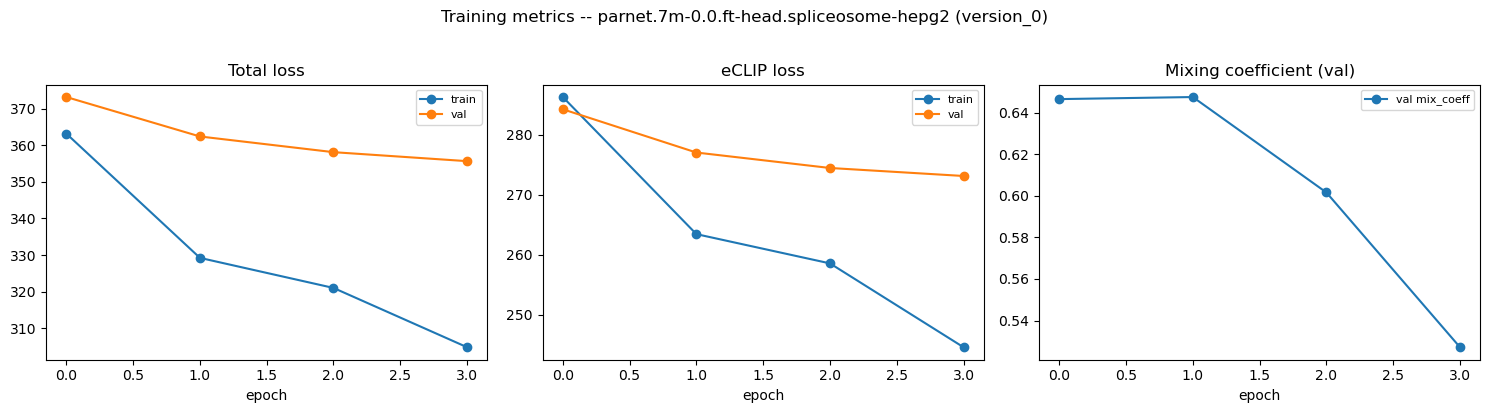

⏱ 0.39 s (00:00:00)


In [10]:
csv_log_dir = FILEPATHS["output_dir"] / "csv_logs"
metrics_paths = sorted(csv_log_dir.glob("version_*/metrics.csv"))
assert metrics_paths, f"No CSV log found under {csv_log_dir} -- run training first."

df_csv = pd.read_csv(metrics_paths[-1])
logger.info(f"Reading metrics from: {metrics_paths[-1]}")
logger.info(f"Available keys: {[c for c in df_csv.columns if c not in ('step', 'epoch')]}")

epoch_df = df_csv.groupby("epoch").last().reset_index()

plots = [
    ({"train": "train/loss_epoch", "val": "val/loss"}, "Total loss"),
    ({"train": "train/loss_eCLIP_epoch", "val": "val/loss_eCLIP"}, "eCLIP loss"),
    ({"val mix_coeff": "val/mix_coeff"}, "Mixing coefficient (val)"),
]

fig, axes = plt.subplots(1, len(plots), figsize=(15, 4))
for (col_dict, title), ax in zip(plots, axes):
    for label, col in col_dict.items():
        if col in epoch_df.columns:
            epoch_df.plot("epoch", col, ax=ax, label=label, marker="o")
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.suptitle(f"Training metrics -- {params_run_id} ({metrics_paths[-1].parent.name})", y=1.02)
plt.tight_layout()
plt.show()

## Test-set evaluation

Runs inference over the full test split and computes per-sequence Pearson r and Spearman rho
between the predicted probability profile and the normalised ground-truth count profile,
for each RBP. Sequences with zero total signal for a given RBP are excluded.

[15:55:21] INFO - Test set: 22388 sequences
INFO:evaluate_retrained_models.py.ipynb:Test set: 22388 sequences
Inference: 100%|██████████| 350/350 [00:19<00:00, 17.88it/s]


RBP           Pearson r (mean+/-std)   n seq
------------------------------------------------
AQR                  0.277 +/- 0.176    9813
BUD13                0.294 +/- 0.142   15156
EFTUD2               0.209 +/- 0.114   11948
PRPF8                0.378 +/- 0.223   13480
RBM22                0.239 +/- 0.120   12302
SF3B4                0.290 +/- 0.156    5350
SMNDC1               0.168 +/- 0.098    5872
U2AF1                0.331 +/- 0.158   18426
U2AF2                0.330 +/- 0.175   16873
------------------------------------------------
Mean r                        0.2797


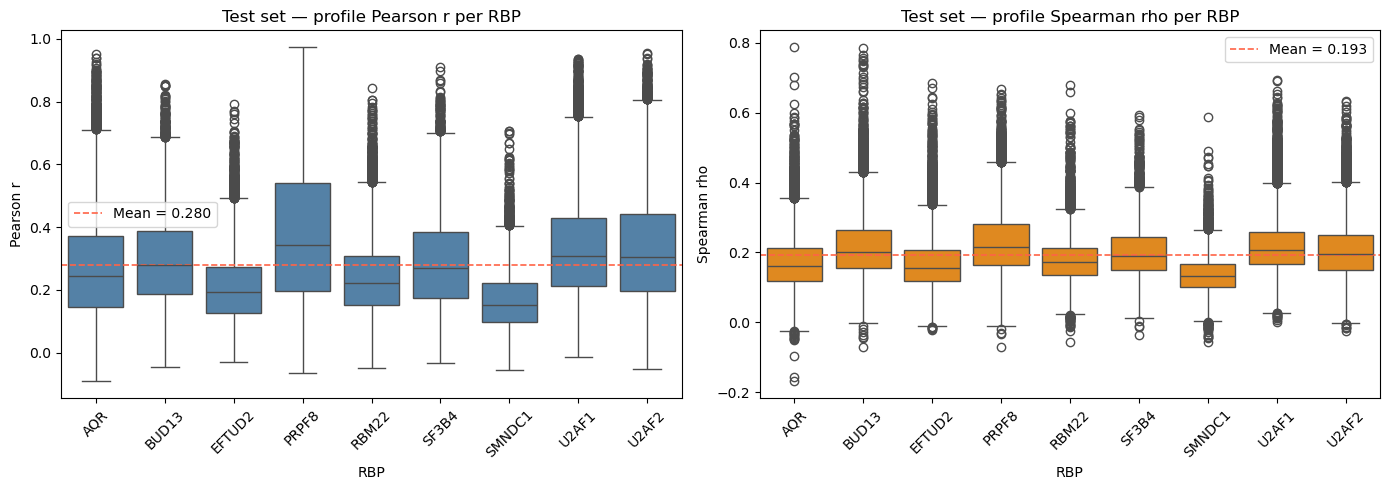

⏱ 41.14 s (00:00:41)


In [ ]:
test_loader = torch.utils.data.DataLoader(
    test_ds, batch_size=params_batch_size, num_workers=4, pin_memory=True
)
logger.info(f"Test set: {len(test_ds)} sequences")

# ── Collect predictions over the full test set ────────────────────────────────
model_reloaded.eval()
_pred_chunks, _tgt_chunks = [], []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Inference"):
        seq = batch["inputs"]["sequence"].to(device)
        out = model_reloaded(seq)
        _pred_chunks.append(out["total"].cpu()) # compare total against labels (sum of output layers)
        _tgt_chunks.append(batch["outputs"]["total"].float())

all_pred_logprob = torch.cat(_pred_chunks)  # (N, T, L)
all_targets_raw = torch.cat(_tgt_chunks)    # (N, T, L)
del _pred_chunks, _tgt_chunks


# ── Correlation helpers ───────────────────────────────────────────────────────
def _batch_pearsonr(x, y):
    xm = x - x.mean(axis=1, keepdims=True)
    ym = y - y.mean(axis=1, keepdims=True)
    num = (xm * ym).sum(axis=1)
    denom = np.sqrt((xm**2).sum(axis=1) * (ym**2).sum(axis=1))
    return np.where(denom > 1e-10, num / denom, np.nan) # shape: (N,) - Pearson r per tile, NaN if denominator is too small


def _batch_spearmanr(x, y):
    xr = np.apply_along_axis(rankdata, 1, x)
    yr = np.apply_along_axis(rankdata, 1, y)
    return _batch_pearsonr(xr, yr) # shape: (N,) - Spearman rho per tile, NaN if denominator is too small


pred_prob = all_pred_logprob.exp()   # (N, T, L)
count_total = all_targets_raw.sum(-1, keepdim=True).clamp(min=1) # (N, T, 1)
target_prob = all_targets_raw / count_total  # (N, T, L) - get relative distribution - we compare shape, not absolute counts

rbp_names = [ct.replace("_HepG2", "") for ct in rbp_cts]

per_rbp_r = []
per_rbp_rho = []

for task_i in range(len(rbp_cts)):
    has_signal = all_targets_raw[:, task_i, :].sum(-1) >= PARAMS_MIN_RC_SUM # shape: (N,) per task - only include tiles with sufficient read counts for this RBP - measured from targets!
    if not has_signal.any(): # skip RBPs with no valid tiles
        per_rbp_r.append(np.array([]))
        per_rbp_rho.append(np.array([]))
        continue
    pred_i = pred_prob[has_signal, task_i, :].numpy()
    tgt_i = target_prob[has_signal, task_i, :].numpy()
    per_rbp_r.append(_batch_pearsonr(pred_i, tgt_i))
    per_rbp_rho.append(_batch_spearmanr(pred_i, tgt_i))

# per_rbp_r and per_rbp_rho are lists of arrays, one array per RBP, containing the Pearson r and Spearman rho values for each tile with sufficient read counts.

mean_r = float(np.nanmean([np.nanmean(rs) for rs in per_rbp_r if len(rs)]))
mean_rho = float(np.nanmean([np.nanmean(rhos) for rhos in per_rbp_rho if len(rhos)]))

# ── Print table ───────────────────────────────────────────────────────────────
print(f"{'RBP':<12s}  {'Pearson r (mean+/-std)':>22s}  {'n seq':>6s}")
print("-" * 48)
for name, rs in zip(rbp_names, per_rbp_r):
    n = len(rs)
    val = f"{np.nanmean(rs):.3f} +/- {np.nanstd(rs):.3f}" if n else "--"
    print(f"{name:<12s}  {val:>22s}  {n:>6d}")
print("-" * 48)
print(f"{'Mean r':<12s}  {mean_r:>22.4f}")

# ── Seaborn boxplots ──────────────────────────────────────────────────────────
_rows_r, _rows_rho = [], []
for name, rs, rhos in zip(rbp_names, per_rbp_r, per_rbp_rho):
    if len(rs) >= PARAMS_MIN_TILES_BOX:
        _rows_r.extend({"RBP": name, "Pearson r": float(v)} for v in rs)
        _rows_rho.extend({"RBP": name, "Spearman rho": float(v)} for v in rhos)

df_pearson  = pd.DataFrame(_rows_r)
df_spearman = pd.DataFrame(_rows_rho)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_pearson,  x="RBP", y="Pearson r",    ax=ax1, color="steelblue")
ax1.axhline(mean_r, color="tomato", linestyle="--", linewidth=1.2, label=f"Mean = {mean_r:.3f}")
ax1.set_title("Test set — profile Pearson r per RBP")
ax1.tick_params(axis="x", rotation=45)
ax1.legend()

sns.boxplot(data=df_spearman, x="RBP", y="Spearman rho", ax=ax2, color="darkorange")
ax2.axhline(mean_rho, color="tomato", linestyle="--", linewidth=1.2, label=f"Mean = {mean_rho:.3f}")
ax2.set_title("Test set — profile Spearman rho per RBP")
ax2.tick_params(axis="x", rotation=45)
ax2.legend()

plt.tight_layout()
plt.show()

## Profile comparison: fine-tuned vs pretrained

Picks the test sequence with the highest combined eCLIP signal across the selected
RBPs (`params_show_rbp_names`) and shows a 3-row x N-column grid:

| Row | Colour | What |
|---|---|---|
| Ground truth | blue | Raw eCLIP read counts from the test set |
| Fine-tuned | orange | Predicted probability profile from the fine-tuned model |
| Pretrained | green | Predicted probability profile from the original pretrained model |

[16:13:18] INFO - Selected test sequence #6605  (combined signal for ['PRPF8', 'U2AF2', 'AQR']: 4283 reads)
INFO:evaluate_retrained_models.py.ipynb:Selected test sequence #6605  (combined signal for ['PRPF8', 'U2AF2', 'AQR']: 4283 reads)


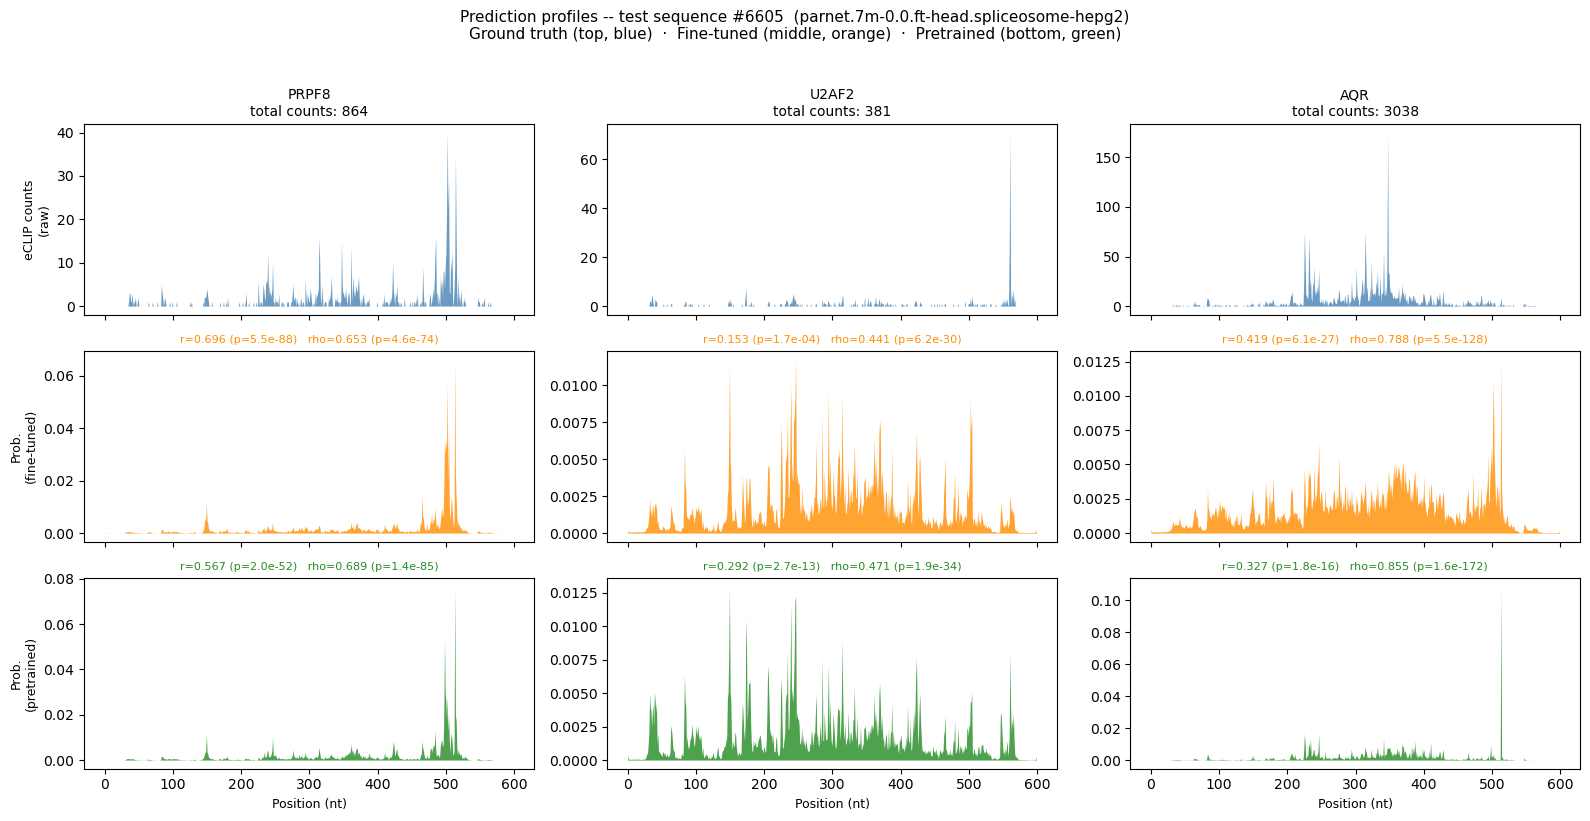

⏱ 1.01 s (00:00:01)


In [12]:
# ── Reload original pretrained model (unmodified 223-task head) ──────────────
# We must reload from disk because the fine-tuned model has a replaced head.
# This gives us the baseline: what the pretrained backbone predicts before fine-tuning.
_model_pretrained = load_parnet_model(
    pretrained_model_name,
    FILEPATHS["pretrained_model"],
    dtype=torch.float32,
    device=device,
)
_model_pretrained.eval()

# ── Select RBPs and find their indices ───────────────────────────────────────
_show_names = params_show_rbp_names
_show_ft_idx = [rbp_cts.index(f"{n}_HepG2") for n in _show_names]

# Corresponding task indices in the full 223-task pretrained head (from rbp_cts.tsv sidecar).
_show_pt_idx = [_pretrained_task_indices[i] for i in _show_ft_idx]

# ── Find test sequence with the strongest combined signal ─────────────────────
_signal = all_targets_raw[:, _show_ft_idx, :].sum(dim=[-1, -2])
_seq_idx = int(_signal.argmax())
_gt_counts = all_targets_raw[_seq_idx]  # (T, L) raw eCLIP read counts
logger.info(
    f"Selected test sequence #{_seq_idx}  "
    f"(combined signal for {_show_names}: {int(_signal[_seq_idx])} reads)"
)

# ── Run both models on the selected sequence ──────────────────────────────────
_seq_tensor = test_ds[_seq_idx]["inputs"]["sequence"].float().unsqueeze(0).to(device)

with torch.no_grad():
    _out_ft = model_reloaded(_seq_tensor)
    _out_pt = _model_pretrained(_seq_tensor)

_prob_ft = _out_ft["total"][0].cpu().exp()  # (T, L)
_prob_pt = _out_pt["total"][0].cpu().exp()  # (223, L)

# ── 3-row x N-column grid ─────────────────────────────────────────────────────
_pos = np.arange(params_seq_length)

fig, axes = plt.subplots(3, len(_show_names), figsize=(16, 8), sharex=True)
fig.suptitle(
    f"Prediction profiles -- test sequence #{_seq_idx}  ({params_run_id})\n"
    "Ground truth (top, blue)  ·  Fine-tuned (middle, orange)  ·  Pretrained (bottom, green)",
    y=1.02,
    fontsize=11,
)

_kw = dict(linewidth=0)
for col, (name, fi, pi) in enumerate(zip(_show_names, _show_ft_idx, _show_pt_idx)):
    gt_raw = _gt_counts[fi].numpy()
    pf = _prob_ft[fi].numpy()
    pp = _prob_pt[pi].numpy()

    r_ft, p_ft = pearsonr(pf, gt_raw)
    rho_ft, sp_ft = spearmanr(pf, gt_raw)
    r_pt, p_pt = pearsonr(pp, gt_raw)
    rho_pt, sp_pt = spearmanr(pp, gt_raw)

    axes[0, col].fill_between(_pos, gt_raw, alpha=0.80, color="steelblue", **_kw)
    axes[0, col].set_title(f"{name}\ntotal counts: {int(gt_raw.sum())}", fontsize=10)

    axes[1, col].fill_between(_pos, pf, alpha=0.80, color="darkorange", **_kw)
    axes[1, col].set_title(
        f"r={r_ft:.3f} (p={p_ft:.1e})   rho={rho_ft:.3f} (p={sp_ft:.1e})",
        fontsize=8,
        color="darkorange",
    )

    axes[2, col].fill_between(_pos, pp, alpha=0.80, color="forestgreen", **_kw)
    axes[2, col].set_title(
        f"r={r_pt:.3f} (p={p_pt:.1e})   rho={rho_pt:.3f} (p={sp_pt:.1e})",
        fontsize=8,
        color="forestgreen",
    )
    axes[2, col].set_xlabel("Position (nt)", fontsize=9)

axes[0, 0].set_ylabel("eCLIP counts\n(raw)", fontsize=9)
axes[1, 0].set_ylabel("Prob.\n(fine-tuned)", fontsize=9)
axes[2, 0].set_ylabel("Prob.\n(pretrained)", fontsize=9)

plt.tight_layout()
plt.show()

del _model_pretrained